In [1]:
import os
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except:
    !pip install seaborn
    import seaborn as sns
try:
    import xgboost as xgb
except:
    !pip install "xgboost<3"
    import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, log_loss, classification_report,
    confusion_matrix
)

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


#### Constants

In [2]:
str_bucket = os.getcwd().split('/')[4].replace('_','-')
print(f'Bucket: {str_bucket}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_dirname_output = './output'
os.makedirs(str_dirname_output, exist_ok=True)

str_dirname_model = '../04_model/output'

Bucket: assessment-swish-analytics
Task: 05_model_eval


#### Import Predictions and Model from Local Output

In [3]:
# load test predictions
df_preds = pd.read_csv(f'{str_dirname_model}/test_predictions.csv')

# load label encoder
le = joblib.load(f'{str_dirname_model}/label_encoder.joblib')

# load model
model = xgb.Booster()
model.load_model(f'{str_dirname_model}/xgb_model.json')

# load params
with open(f'{str_dirname_model}/params.json', 'r') as f:
    dict_params = json.load(f)

arr_classes = le.classes_
y_actual = df_preds['actual']
y_pred = df_preds['predicted']
arr_proba = df_preds[[f'prob_{c}' for c in arr_classes]].values

print(f'Test set size: {len(df_preds):,}')
print(f'Classes: {arr_classes}')

Test set size: 39,545
Classes: ['CH' 'CU' 'FC' 'FF' 'FS' 'FT' 'SI' 'SL']


#### Overall Metrics

In [4]:
y_actual_enc = le.transform(y_actual)

flt_accuracy = accuracy_score(y_actual, y_pred)
flt_logloss = log_loss(y_actual_enc, arr_proba)

print(f'Test Accuracy: {flt_accuracy:.4f}')
print(f'Test Log-Loss: {flt_logloss:.4f}')
print(f'Best iteration: {dict_params.get("best_iteration", "N/A")}')

Test Accuracy: 0.3993
Test Log-Loss: 1.7325
Best iteration: 13


/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


#### Baselines Comparison

In [5]:
# load train and test raw data from S3 to compute baselines
y_train = pd.read_csv(f's3://{str_bucket}/03_preprocessing/y_train.csv').squeeze()
df_train_raw = pd.read_csv(f's3://{str_bucket}/02_data_split/train.csv')
df_test_raw = pd.read_csv(f's3://{str_bucket}/02_data_split/test.csv')

# baseline 1: always predict most common pitch type
str_most_common = y_train.mode()[0]
flt_baseline1 = accuracy_score(y_actual, [str_most_common] * len(y_actual))

# baseline 2: predict each pitcher's most common pitch type (from train)
sr_pitcher_mode = df_train_raw.groupby('pitcher_id')['pitch_type'].agg(lambda x: x.mode()[0])
arr_baseline2 = df_test_raw['pitcher_id'].map(sr_pitcher_mode).fillna(str_most_common)
flt_baseline2 = accuracy_score(y_actual, arr_baseline2)

# baseline 3: pitcher mode per count (from train)
df_train_raw['count_str'] = df_train_raw['balls'].astype(str) + '-' + df_train_raw['strikes'].astype(str)
df_test_raw['count_str'] = df_test_raw['balls'].astype(str) + '-' + df_test_raw['strikes'].astype(str)
sr_pitcher_count_mode = df_train_raw.groupby(['pitcher_id', 'count_str'])['pitch_type'].agg(lambda x: x.mode()[0])
arr_baseline3 = df_test_raw.set_index(['pitcher_id', 'count_str']).index.map(
    sr_pitcher_count_mode
)
arr_baseline3 = pd.Series(arr_baseline3).fillna(
    df_test_raw['pitcher_id'].map(sr_pitcher_mode).fillna(str_most_common)
).values
flt_baseline3 = accuracy_score(y_actual, arr_baseline3)

print(f'Baseline 1 - Always "{str_most_common}": {flt_baseline1:.4f}')
print(f'Baseline 2 - Pitcher mode:              {flt_baseline2:.4f}')
print(f'Baseline 3 - Pitcher mode per count:     {flt_baseline3:.4f}')
print(f'XGBoost model:                           {flt_accuracy:.4f}')
print(f'\nLift over best baseline: {(flt_accuracy - flt_baseline3)*100:.1f} percentage points')

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/fsspec/registry.py:301: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)
/tmp/ipykernel_7151/3850245782.py:3: DtypeWarning: Columns (29,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train_raw = pd.read_csv(f's3://{str_bucket}/02_data_split/train.csv')
/tmp/ipykernel_7151/3850245782.py:4: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test_raw = pd.read_csv(f's3://{str_bucket}/02_data_split/test.csv')


Baseline 1 - Always "FF": 0.3483
Baseline 2 - Pitcher mode:              0.4562
Baseline 3 - Pitcher mode per count:     0.4715
XGBoost model:                           0.3993

Lift over best baseline: -7.2 percentage points


#### Classification Report

In [6]:
print(classification_report(y_actual, y_pred, target_names=arr_classes))

              precision    recall  f1-score   support

          CH       0.30      0.10      0.15      4047
          CU       0.30      0.12      0.18      3360
          FC       0.40      0.22      0.29      2497
          FF       0.45      0.65      0.54     13774
          FS       0.26      0.11      0.15       633
          FT       0.31      0.29      0.30      4699
          SI       0.38      0.56      0.45      4511
          SL       0.34      0.24      0.28      6024

    accuracy                           0.40     39545
   macro avg       0.34      0.29      0.29     39545
weighted avg       0.38      0.40      0.37     39545



#### Confusion Matrix

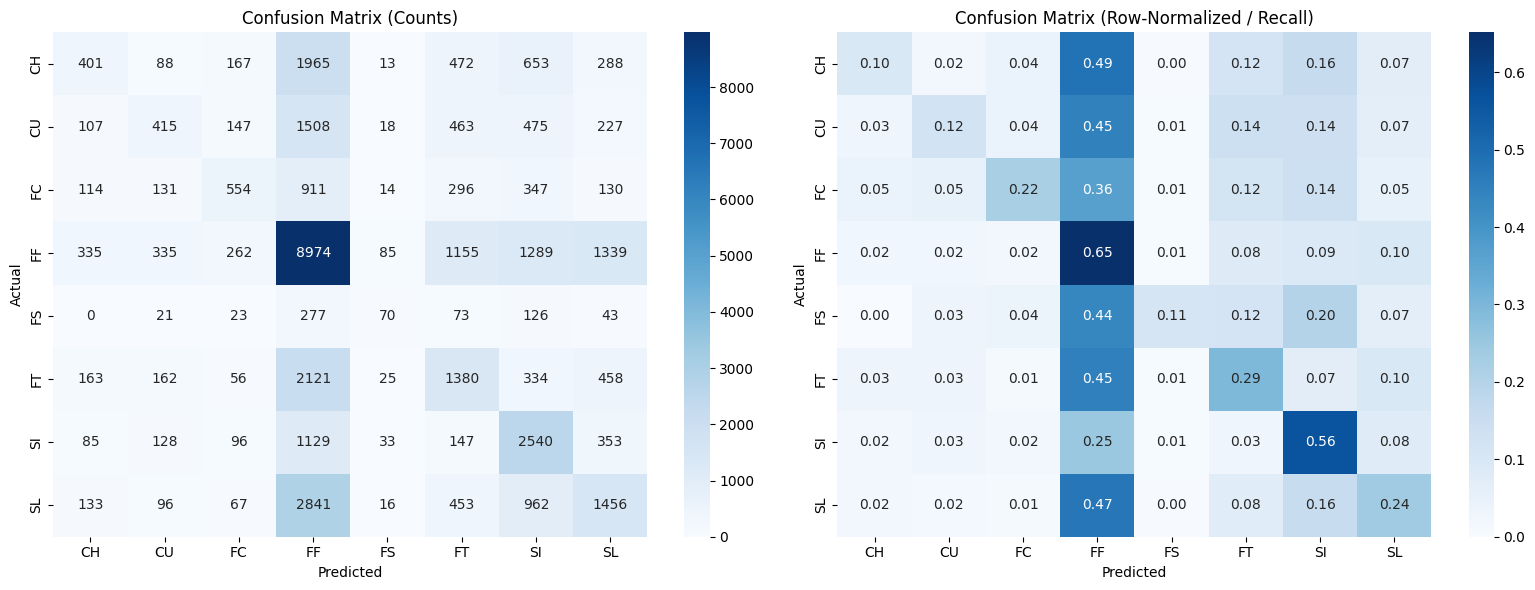

In [7]:
arr_cm = confusion_matrix(y_actual, y_pred, labels=arr_classes)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# raw counts
sns.heatmap(arr_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=arr_classes, yticklabels=arr_classes, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# normalized by row (recall)
arr_cm_norm = arr_cm.astype(float) / arr_cm.sum(axis=1, keepdims=True)
sns.heatmap(arr_cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=arr_classes, yticklabels=arr_classes, ax=axes[1])
axes[1].set_title('Confusion Matrix (Row-Normalized / Recall)')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(f'{str_dirname_output}/confusion_matrix.png', dpi=150)
plt.show()

#### Feature Importance

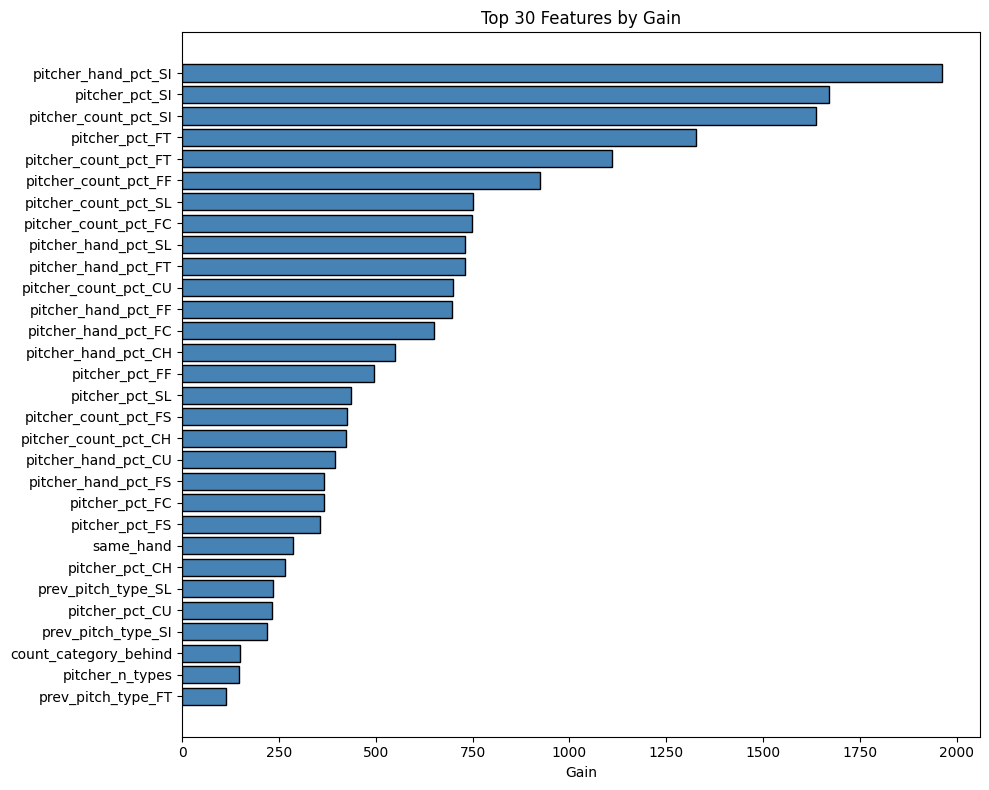

In [8]:
# feature importance (gain)
dict_importance = model.get_score(importance_type='gain')
df_importance = pd.DataFrame({
    'feature': dict_importance.keys(),
    'gain': dict_importance.values()
}).sort_values('gain', ascending=False)

# top 30 features
fig, ax = plt.subplots(figsize=(10, 8))
df_top_feat = df_importance.head(30)
ax.barh(range(len(df_top_feat)), df_top_feat['gain'].values, color='steelblue', edgecolor='black')
ax.set_yticks(range(len(df_top_feat)))
ax.set_yticklabels(df_top_feat['feature'].values)
ax.invert_yaxis()
ax.set_title('Top 30 Features by Gain')
ax.set_xlabel('Gain')
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/feature_importance.png', dpi=150)
plt.show()

#### Calibration Check

For each pitch type, compare predicted probability vs. actual frequency in bins.

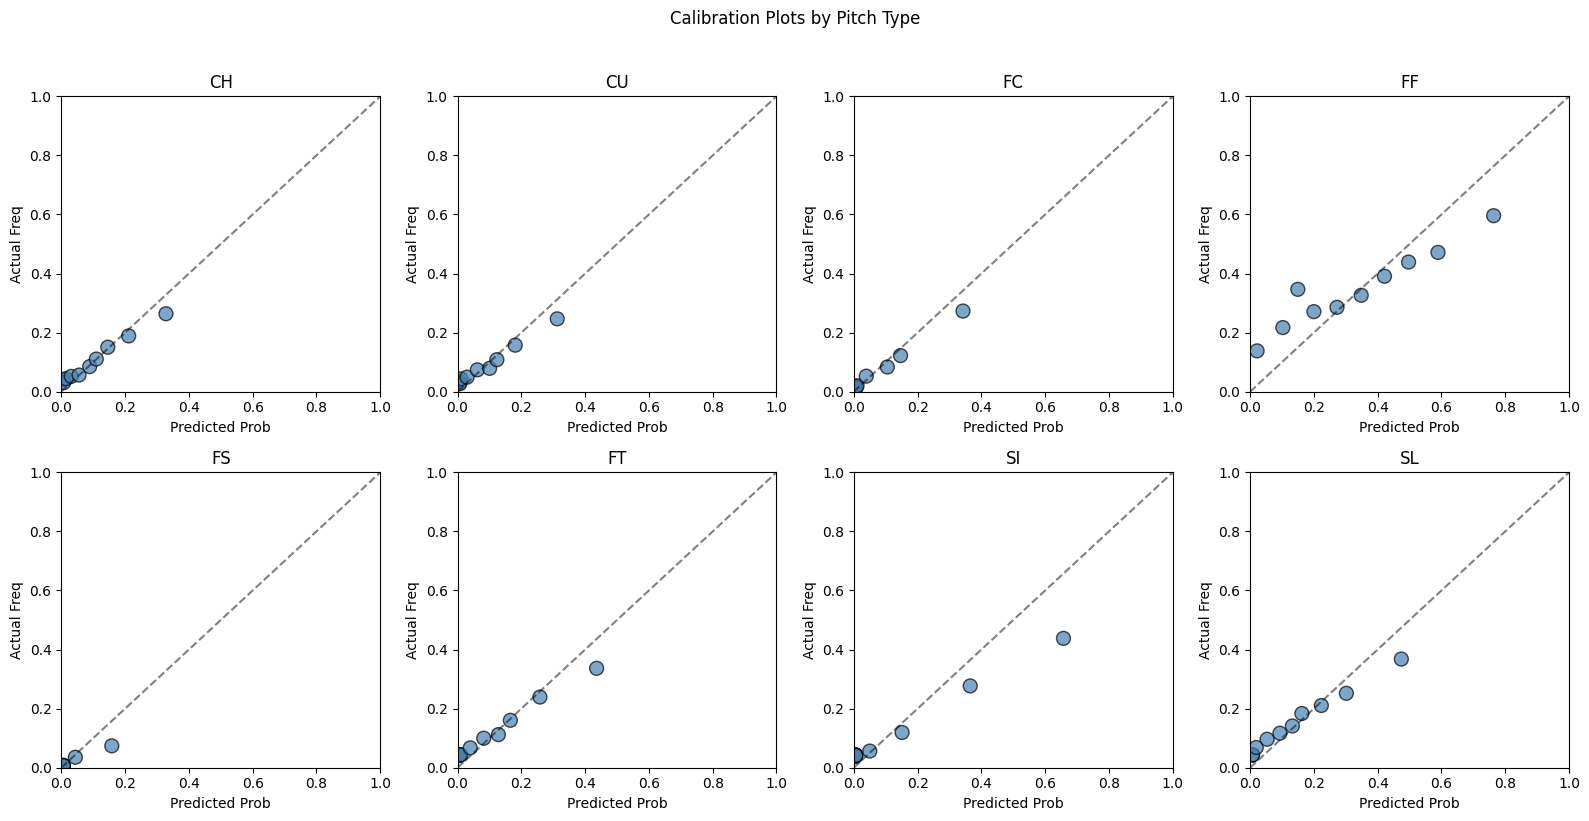

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, str_class in enumerate(arr_classes):
    ax = axes[i]
    arr_prob_class = arr_proba[:, i]
    arr_actual_class = (y_actual == str_class).astype(int).values
    
    # bin predictions into deciles
    df_cal = pd.DataFrame({'prob': arr_prob_class, 'actual': arr_actual_class})
    df_cal['bin'] = pd.qcut(df_cal['prob'], q=10, duplicates='drop')
    df_cal_grouped = df_cal.groupby('bin', observed=True).agg(
        mean_prob=('prob', 'mean'),
        mean_actual=('actual', 'mean'),
        count=('actual', 'size')
    )
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
    ax.scatter(df_cal_grouped['mean_prob'], df_cal_grouped['mean_actual'],
               s=df_cal_grouped['count'] / df_cal_grouped['count'].max() * 100,
               color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{str_class}')
    ax.set_xlabel('Predicted Prob')
    ax.set_ylabel('Actual Freq')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.suptitle('Calibration Plots by Pitch Type', y=1.02)
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/calibration_plots.png', dpi=150, bbox_inches='tight')
plt.show()

#### Prediction Confidence Distribution

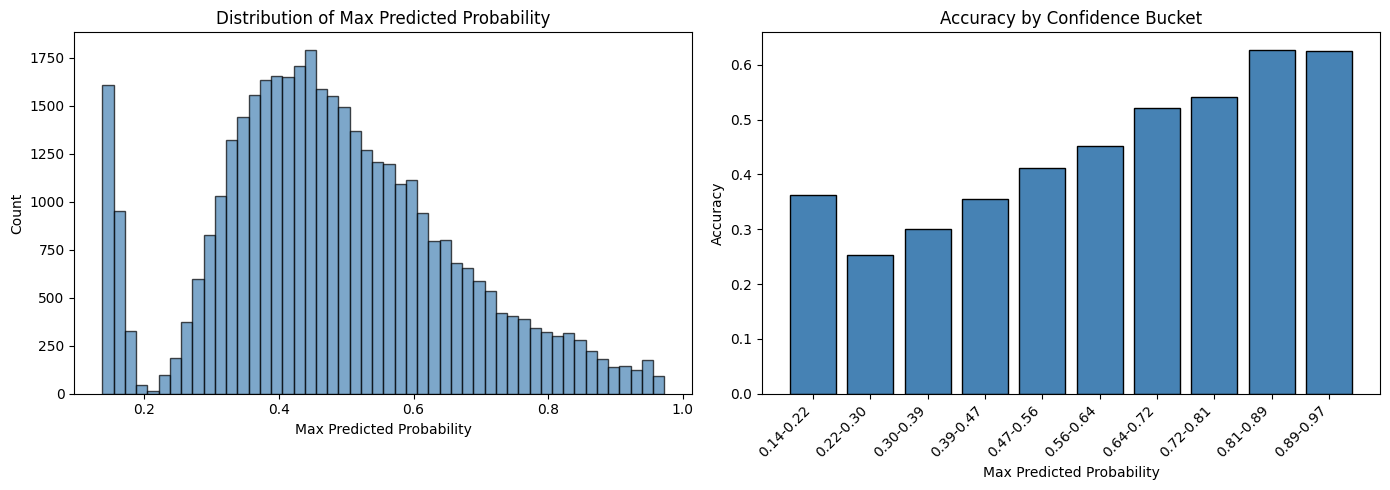

In [10]:
# max predicted probability (confidence) for each pitch
arr_max_prob = arr_proba.max(axis=1)
sr_correct = (y_actual.values == y_pred.values)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# distribution of confidence
axes[0].hist(arr_max_prob, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Max Predicted Probability')
axes[0].set_xlabel('Max Predicted Probability')
axes[0].set_ylabel('Count')

# accuracy by confidence bucket
df_conf = pd.DataFrame({'max_prob': arr_max_prob, 'correct': sr_correct})
df_conf['bin'] = pd.cut(df_conf['max_prob'], bins=10)
df_conf_agg = df_conf.groupby('bin', observed=True).agg(
    accuracy=('correct', 'mean'),
    count=('correct', 'size')
)
ax2 = axes[1]
x_labels = [f'{interval.left:.2f}-{interval.right:.2f}' for interval in df_conf_agg.index]
ax2.bar(range(len(df_conf_agg)), df_conf_agg['accuracy'], color='steelblue', edgecolor='black')
ax2.set_xticks(range(len(df_conf_agg)))
ax2.set_xticklabels(x_labels, rotation=45, ha='right')
ax2.set_title('Accuracy by Confidence Bucket')
ax2.set_xlabel('Max Predicted Probability')
ax2.set_ylabel('Accuracy')

plt.tight_layout()
plt.savefig(f'{str_dirname_output}/confidence_analysis.png', dpi=150)
plt.show()

#### Summary

In [11]:
print('=' * 60)
print('MODEL EVALUATION SUMMARY')
print('=' * 60)
print(f'\nModel: XGBoost multi:softprob')
print(f'Best iteration: {dict_params.get("best_iteration", "N/A")}')
print(f'\n--- Test Set Metrics ---')
print(f'Accuracy:  {flt_accuracy:.4f}')
print(f'Log-Loss:  {flt_logloss:.4f}')
print(f'\n--- Baselines ---')
print(f'Always "{str_most_common}":       {flt_baseline1:.4f}')
print(f'Pitcher mode:             {flt_baseline2:.4f}')
print(f'Pitcher mode per count:   {flt_baseline3:.4f}')
print(f'\n--- Lift ---')
print(f'Over naive:               +{(flt_accuracy - flt_baseline1)*100:.1f} pp')
print(f'Over pitcher mode:        +{(flt_accuracy - flt_baseline2)*100:.1f} pp')
print(f'Over pitcher mode/count:  +{(flt_accuracy - flt_baseline3)*100:.1f} pp')
print('=' * 60)

MODEL EVALUATION SUMMARY

Model: XGBoost multi:softprob
Best iteration: 13

--- Test Set Metrics ---
Accuracy:  0.3993
Log-Loss:  1.7325

--- Baselines ---
Always "FF":       0.3483
Pitcher mode:             0.4562
Pitcher mode per count:   0.4715

--- Lift ---
Over naive:               +5.1 pp
Over pitcher mode:        +-5.7 pp
Over pitcher mode/count:  +-7.2 pp
